# 🌳 Módulo 11: Métodos Ensemble

## Objetivos de Aprendizagem

Ao final deste módulo você será capaz de:

- Compreender a filosofia por trás dos **métodos ensemble** ("a união faz a força")
- Distinguir as estratégias de **Bagging** e **Boosting**
- Entender e aplicar o **Random Forest** (Bagging + seleção aleatória de features)
- Compreender o algoritmo **AdaBoost** e a atualização de pesos
- Aplicar **Gradient Boosting** e **XGBoost** em problemas reais
- Interpretar **Feature Importance** e **OOB Error**
- Comparar todos os métodos ensemble em termos de performance e custo computacional

## Teoria Matemática

### Bagging — Predição por Votação/Média
$$\hat{y}_{\text{bag}} = \frac{1}{T}\sum_{t=1}^T h_t(\mathbf{x}) \quad \text{(regressão)}$$
$$\hat{y}_{\text{bag}} = \text{mode}\{h_1(\mathbf{x}), \ldots, h_T(\mathbf{x})\} \quad \text{(classificação)}$$

### AdaBoost — Atualização de Pesos
$$\alpha_t = \frac{1}{2}\ln\left(\frac{1-\varepsilon_t}{\varepsilon_t}\right)$$
$$w_i^{(t+1)} = w_i^{(t)} \exp(-\alpha_t y_i h_t(\mathbf{x}_i))$$

### Random Forest — Importância (MDI)
$$\text{Importância}(X_j) = \frac{1}{T}\sum_{t=1}^T \sum_{v \in V_j^t} p(v) \cdot \Delta\text{Gini}(v)$$

### XGBoost — Objetivo Regularizado
$$\mathcal{L}^{(t)} = \sum_i l(y_i, \hat{y}_i^{(t)}) + \Omega(f_t)$$
$$\Omega(f) = \gamma T + \frac{1}{2}\lambda\sum_{j=1}^T w_j^2$$

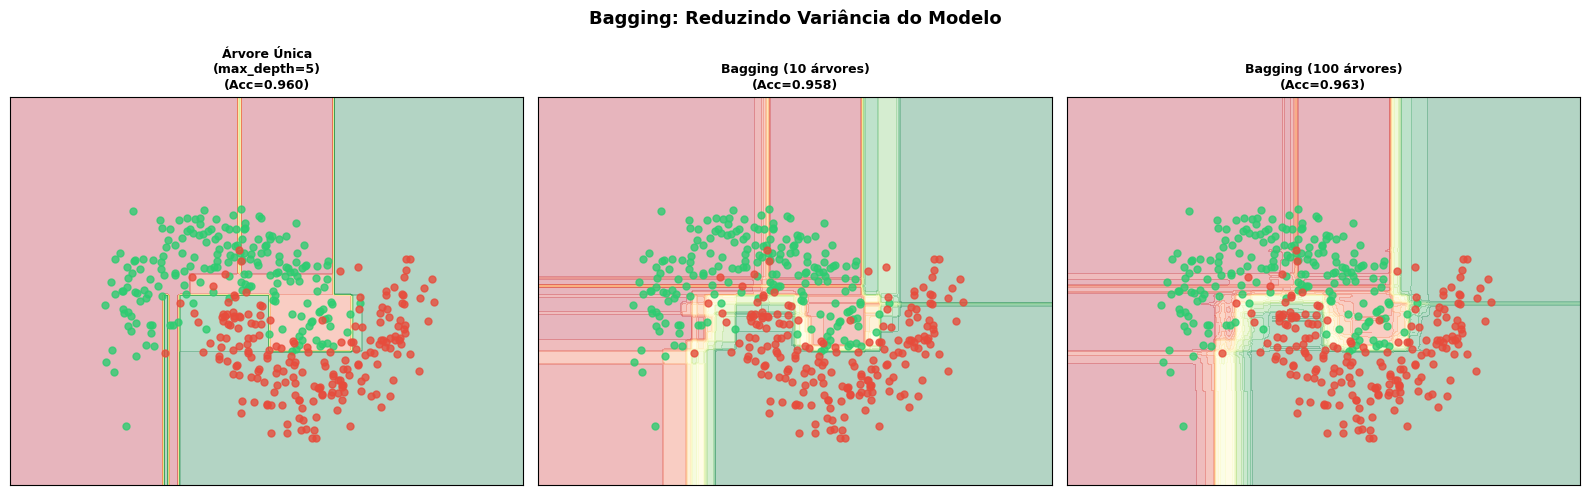

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

# Dataset de fraude bancária
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=10, n_informative=6, 
                             weights=[0.85, 0.15], random_state=42)
feature_names = ['Valor_Trans', 'Hora_Dia', 'Freq_Loja', 'Distancia', 'N_Trans_24h',
                  'Score_Cliente', 'Tempo_Conta', 'Pais_Origem', 'Canal', 'Idade']
X_df = pd.DataFrame(X, columns=feature_names)
X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.25, 
                                                       stratify=y, random_state=42)

# Bagging vs Árvore única (2D para visualização)
from sklearn.datasets import make_moons
X_vis, y_vis = make_moons(n_samples=400, noise=0.25, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Bagging: Reduzindo Variância do Modelo', fontsize=13, fontweight='bold')

for ax, (nome, modelo) in zip(axes, [
    ('Árvore Única\n(max_depth=5)', DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('Bagging (10 árvores)', BaggingClassifier(DecisionTreeClassifier(max_depth=5), n_estimators=10, random_state=42)),
    ('Bagging (100 árvores)', BaggingClassifier(DecisionTreeClassifier(max_depth=5), n_estimators=100, random_state=42)),
]):
    modelo.fit(X_vis, y_vis)
    acc = modelo.score(X_vis, y_vis)
    
    h = 0.05
    xx, yy = np.meshgrid(np.linspace(-2.5, 3.5, 200), np.linspace(-1.5, 2.5, 200))
    Z = modelo.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn', levels=20)
    ax.scatter(X_vis[y_vis==0,0], X_vis[y_vis==0,1], c='#2ecc71', s=25, alpha=0.8)
    ax.scatter(X_vis[y_vis==1,0], X_vis[y_vis==1,1], c='#e74c3c', s=25, alpha=0.8)
    ax.set_title(f'{nome}\n(Acc={acc:.3f})', fontweight='bold', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.savefig('../imagens/11_bagging_fronteiras.png', dpi=150, bbox_inches='tight')
plt.show()

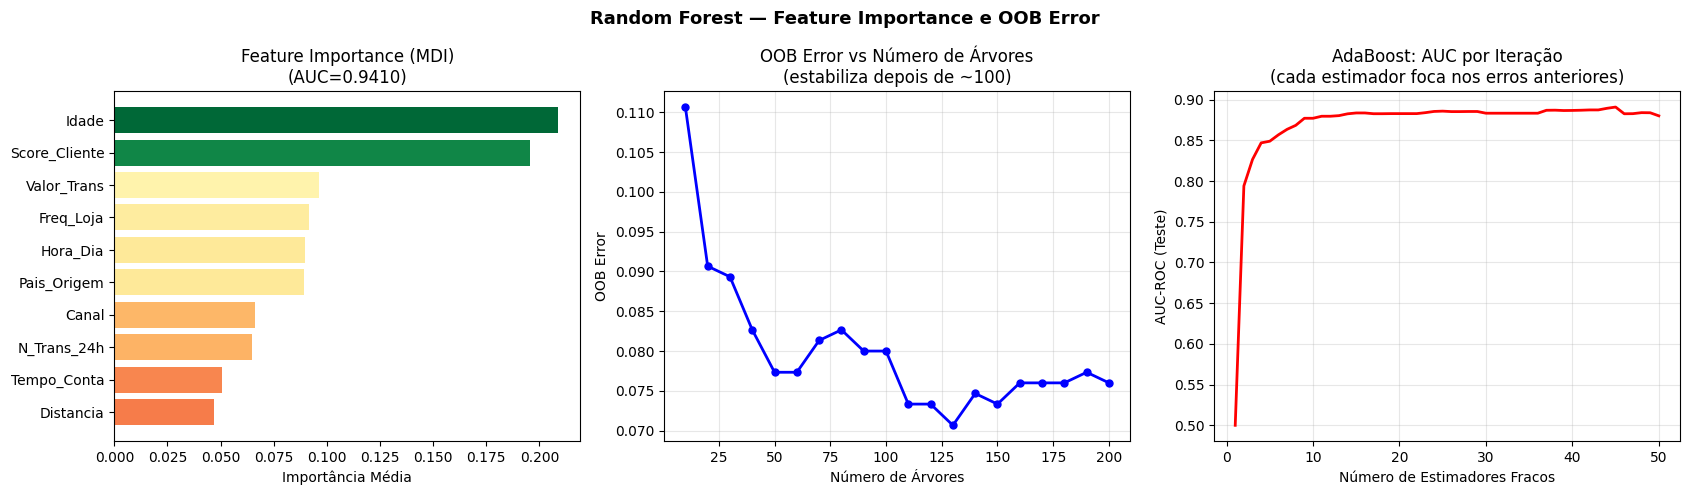

OOB Score do RF: 0.9240


In [2]:
# Random Forest
rf = RandomForestClassifier(n_estimators=200, oob_score=True, random_state=42)
rf.fit(X_train, y_train)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Random Forest — Feature Importance e OOB Error', fontsize=13, fontweight='bold')

# Feature Importance
importances = rf.feature_importances_
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values('Importance')
colors_fi = plt.cm.RdYlGn(fi_df['Importance'] / fi_df['Importance'].max())
axes[0].barh(fi_df['Feature'], fi_df['Importance'], color=colors_fi)
axes[0].set_title(f'Feature Importance (MDI)\n(AUC={roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]):.4f})')
axes[0].set_xlabel('Importância Média')

# OOB Error vs N estimadores
oob_erros = []
n_range = range(10, 201, 10)
for n in n_range:
    rf_temp = RandomForestClassifier(n_estimators=n, oob_score=True, random_state=42)
    rf_temp.fit(X_train, y_train)
    oob_erros.append(1 - rf_temp.oob_score_)
axes[1].plot(n_range, oob_erros, 'b-o', lw=2, ms=5)
axes[1].set_xlabel('Número de Árvores'); axes[1].set_ylabel('OOB Error')
axes[1].set_title('OOB Error vs Número de Árvores\n(estabiliza depois de ~100)')
axes[1].grid(True, alpha=0.3)

# AdaBoost: pesos por iteração (simplificado)
n_iter = 50
adaboost_scores = []
for n in range(1, n_iter+1):
    ab = AdaBoostClassifier(n_estimators=n, random_state=42)
    ab.fit(X_train, y_train)
    adaboost_scores.append(roc_auc_score(y_test, ab.predict_proba(X_test)[:,1]))
axes[2].plot(range(1, n_iter+1), adaboost_scores, 'r-', lw=2)
axes[2].set_xlabel('Número de Estimadores Fracos'); axes[2].set_ylabel('AUC-ROC (Teste)')
axes[2].set_title('AdaBoost: AUC por Iteração\n(cada estimador foca nos erros anteriores)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../imagens/11_rf_adaboost.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"OOB Score do RF: {rf.oob_score_:.4f}")


🏆 Comparação Final dos Ensemble:


,AUC Teste,CV AUC Média,CV AUC ±dp,Tempo (s)
Modelo,,,,
XGBoost,0.9505,0.9537,0.0175,0.6
Random Forest,0.9410,0.9450,0.0237,1.8
Gradient Boosting,0.9387,0.9340,0.0180,1.1
Bagging (100),0.9310,0.9332,0.0294,1.7
AdaBoost (100),0.8971,0.8769,0.0164,0.9
Árvore Única,0.7903,0.8533,0.0252,0.0


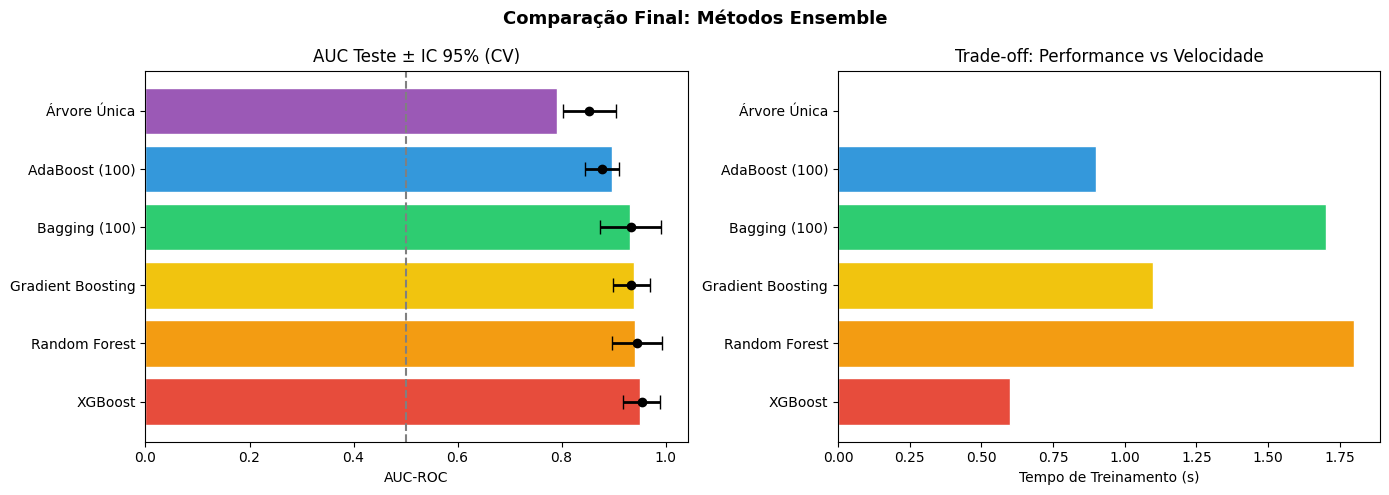

In [3]:
# Comparação final de todos os ensemble
modelos_ensemble = {
    'Árvore Única': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Bagging (100)': BaggingClassifier(DecisionTreeClassifier(max_depth=6), n_estimators=100, random_state=42),
    'AdaBoost (100)': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42),
}

if HAS_XGB:
    modelos_ensemble['XGBoost'] = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, 
                                                       eval_metric='logloss', random_state=42, verbosity=0)

import time
resultados_ens = []
for nome, modelo in modelos_ensemble.items():
    t0 = time.time()
    cv_scores = cross_val_score(modelo, X_df, y, cv=5, scoring='roc_auc')
    tempo = time.time() - t0
    modelo.fit(X_train, y_train)
    auc_test = roc_auc_score(y_test, modelo.predict_proba(X_test)[:,1])
    resultados_ens.append({
        'Modelo': nome, 'AUC Teste': round(auc_test, 4),
        'CV AUC Média': round(cv_scores.mean(), 4), 
        'CV AUC ±dp': round(cv_scores.std(), 4),
        'Tempo (s)': round(tempo, 1)
    })

df_ens = pd.DataFrame(resultados_ens).set_index('Modelo').sort_values('AUC Teste', ascending=False)
print("\n🏆 Comparação Final dos Ensemble:")
display(df_ens)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparação Final: Métodos Ensemble', fontsize=13, fontweight='bold')

cores_ens = ['#e74c3c','#f39c12','#f1c40f','#2ecc71','#3498db','#9b59b6'][:len(df_ens)]
axes[0].barh(df_ens.index, df_ens['AUC Teste'], color=cores_ens, edgecolor='white')
axes[0].errorbar(df_ens['CV AUC Média'], range(len(df_ens)), 
                  xerr=df_ens['CV AUC ±dp']*2, fmt='ko', capsize=5, lw=2)
axes[0].set_xlabel('AUC-ROC'); axes[0].set_title('AUC Teste ± IC 95% (CV)')
axes[0].axvline(0.5, color='gray', lw=1.5, linestyle='--')

axes[1].barh(df_ens.index, df_ens['Tempo (s)'], color=cores_ens, edgecolor='white')
axes[1].set_xlabel('Tempo de Treinamento (s)'); axes[1].set_title('Trade-off: Performance vs Velocidade')

plt.tight_layout()
plt.savefig('../imagens/11_comparacao_ensemble.png', dpi=150, bbox_inches='tight')
plt.show()

## Resumo e Comparação dos Métodos Ensemble

| Método | Estratégia | Paralelizável | Overfitting | Velocidade | Melhor Para |
|--------|------------|:-------------:|:-----------:|:----------:|-------------|
| **Bagging** | Votação de modelos em subamostras bootstrap | Sim | Baixo | Rápido | Reduzir variância de modelos instáveis |
| **Random Forest** | Bagging + features aleatórias por nó | Sim | Baixo | Rápido | Ponto de partida geral, feature importance |
| **AdaBoost** | Boosting com re-ponderação de amostras | Não | Médio | Médio | Quando o sinal é fraco, dados balanceados |
| **Gradient Boosting** | Boosting via gradiente do erro residual | Não | Alto | Lento | Alta acurácia, dados tabulares |
| **XGBoost** | Gradient Boosting regularizado + otimizações | Parcial | Médio | Rápido | Competições Kaggle, produção em tabular |

### Guia de Seleção

- **Random Forest** é o ponto de partida ideal: rápido, robusto, bom out-of-the-box
- **XGBoost/LightGBM** quando você precisa espremertoda a performance possível
- **AdaBoost** quando os dados são relativamente limpos e o sinal é fraco
- **Bagging** quando seu modelo base é muito instável (árvores profundas)
- Sempre compare com uma **Árvore Única** como baseline

### Pontos-Chave

- **Bias-Variance Trade-off**: Bagging reduz variância; Boosting reduz viés
- **OOB Error** do Random Forest é uma estimativa de generalização gratuita (sem CV separado)
- **Feature Importance** (MDI) pode ser inflada para features de alta cardinalidade — use permutation importance como alternativa
- **XGBoost** adiciona regularização L1/L2 nas folhas para evitar overfitting

## Exercícios Propostos

1. **Stacking**: implemente um ensemble de segundo nível (meta-modelo) combinando Random Forest, XGBoost e Regressão Logística com `StackingClassifier`.
2. **Tuning do XGBoost**: use `GridSearchCV` ou `Optuna` para otimizar `n_estimators`, `max_depth`, `learning_rate` e `subsample`.
3. **Feature Importance permutacional**: compare `rf.feature_importances_` (MDI) com `permutation_importance` — as rankings concordam?
4. **LightGBM vs XGBoost**: instale `lightgbm` e compare velocidade e AUC no dataset de fraude.
5. **Análise de OOB**: use o OOB error do Random Forest como proxy para a curva de validação — ele converge para o mesmo valor que a validação cruzada?